# Where to pilot Visa QR Pay?

No new model: the readiness model (`readiness_model.ipynb`) is applied to **today's** cards and its scores
are summed per region. Two pilot tracks need different regions:

| Track | Goal | Region metric |
|---|---|---|
| **Replace typing** | QR replaces card numbers typed at online checkout | typed online card payments per 1,000 active cards (last 6 months) |
| **First online payment** | QR is the first online card payment of cards that do not pay online yet | room to grow (share of cards never paying online) and expected first online payments in the next 3 months (sum of calibrated model scores) |

For every pilot region a **control region** is chosen by nearest-neighbour matching on behaviour, and
checked for **parallel pre-trends** (monthly online usage over 18 months), so the pilot effect can be measured.

- "Today" = snapshot Jul 2026 (T = 18): features from Jan-Jun 2026; this period has no label yet.
- Region = home area (FUA) assigned to the card, i.e. where the cardholder lives: this is where a bank campaign reaches them.
- Only regions with at least 3,000 active cards are ranked; every figure is an aggregate of far more than 30 cards.
- Data are synthetic, so the named cities illustrate the method.

In [1]:
import json
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

import readiness as rd

TODAY = 18
TRAIN, CALIBRATE = [6, 9, 12], 15
MIN_REGION_CARDS = 3000
N_PILOTS = 2  # per track
MAX_MDE_PP = 1.0  # a pilot must be able to detect a +1 pp change in its KPI
RNG = 42

con = rd.connect()
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

## 1. Score today's cards with the readiness model

In [2]:
rd.build_snapshot(con, TODAY, labelled=False)

def load(t):
    d = pd.read_parquet(rd.FEATURES / f"t{t:02d}.parquet")
    for c in d.select_dtypes("float64").columns:
        d[c] = d[c].astype("float32")
    return d

labelled = pd.concat([load(t) for t in TRAIN + [CALIBRATE]], ignore_index=True)
today = load(TODAY)
CATEGORIES = {c: sorted(pd.concat([labelled[c], today[c]]).fillna("UNKNOWN").unique()) for c in rd.CAT}

def X_of(d):
    X = d[rd.NUM + rd.CAT].copy()
    for c in rd.CAT:
        X[c] = pd.Categorical(X[c].fillna("UNKNOWN"), categories=CATEGORIES[c])
    return X

train = labelled[labelled.snapshot.isin(TRAIN)]
cal = labelled[labelled.snapshot == CALIBRATE]
model = lgb.LGBMClassifier(**rd.BEST_PARAMS, random_state=RNG, verbose=-1)
model.fit(X_of(train), train.label, categorical_feature=rd.CAT)
p_cal_raw = model.predict_proba(X_of(cal))[:, 1]
iso = IsotonicRegression(out_of_bounds="clip").fit(p_cal_raw, cal.label)
print(f"check on Apr 2026 (calibration period): AUC {roc_auc_score(cal.label, p_cal_raw):.3f}, "
      f"mean calibrated {iso.predict(p_cal_raw).mean():.2%} vs actual {cal.label.mean():.2%}")

today["p"] = iso.predict(model.predict_proba(X_of(today))[:, 1])
top10_cut = np.quantile(today.p, 0.9)
print(f"today: {len(today):,} never-online active cards, expected to start within 3 months: "
      f"{today.p.sum():,.0f} ({today.p.mean():.1%})")

check on Apr 2026 (calibration period): AUC 0.757, mean calibrated 4.92% vs actual 4.92%


today: 274,209 never-online active cards, expected to start within 3 months: 14,815 (5.4%)


## 2. Region indicators

In [3]:
# Typing and activity over the last 6 months (Jan-Jun 2026), all active cards with a known home area
cards_6m = con.sql(f'''
    WITH w AS (
        SELECT card, sum(n_online) AS n_online, sum(n_online_manual) AS n_typed,
               sum(n_store) AS n_store, sum(n_wallet_store) AS n_wallet
        FROM panel WHERE m BETWEEN {TODAY} - 6 AND {TODAY} - 1
        GROUP BY card HAVING count(*) >= 3
    )
    SELECT a.home_fua AS region,
           count(*) AS active_cards,
           count(*) FILTER (WHERE n_online > 0) AS online_cards,
           count(*) FILTER (WHERE n_online > 0 AND n_typed >= 0.5 * n_online) AS mostly_typing_cards,
           sum(n_online) AS online_tx,
           sum(n_typed) AS typed_tx,
           avg((n_wallet >= 0.5 * n_store)::INT) AS mostly_wallet_share
    FROM w JOIN attrs a USING (card)
    WHERE a.home_fua IS NOT NULL
    GROUP BY 1
''').df()

scores = today.dropna(subset=["home_fua"]).groupby("home_fua").agg(
    scored_cards=("p", "size"), expected_starters=("p", "sum"),
    top10_cards=("p", lambda s: (s >= top10_cut).sum()), new_card_share=("card_age_months", lambda s: (s <= 6).mean()))

reg = cards_6m.merge(scores, left_on="region", right_index=True, how="left").fillna({"expected_starters": 0})
reg = reg[reg.active_cards >= MIN_REGION_CARDS].reset_index(drop=True)
reg["online_share"] = reg.online_cards / reg.active_cards
reg["typing_share"] = reg.typed_tx / reg.online_tx
reg["mostly_typing_share"] = reg.mostly_typing_cards / reg.active_cards
reg["typed_per_1000"] = reg.typed_tx / reg.active_cards * 1000
reg["starters_per_1000"] = reg.expected_starters / reg.active_cards * 1000
reg["never_online_share"] = 1 - reg.online_share
print(f"{len(reg)} regions with >= {MIN_REGION_CARDS:,} active cards")
reg.sort_values("active_cards", ascending=False).head(10)

57 regions with >= 3,000 active cards


,region,active_cards,online_cards,mostly_typing_cards,online_tx,typed_tx,mostly_wallet_share,scored_cards,expected_starters,top10_cards,new_card_share,online_share,typing_share,mostly_typing_share,typed_per_1000,starters_per_1000,never_online_share
18,WARSZAWA,112983,71026,31967,"1,720,958.00","850,520.00",0.44,"28,884.00","1,907.91","4,123.00",0.08,0.63,0.49,0.28,"7,527.86",16.89,0.37
8,KATOWICE,67536,34629,12724,"621,077.00","262,887.00",0.35,"25,020.00","1,168.44","2,028.00",0.06,0.51,0.42,0.19,"3,892.55",17.30,0.49
36,KRAKOW,51811,31797,14145,"689,598.00","339,298.00",0.42,"13,166.00",786.58,"1,607.00",0.06,0.61,0.49,0.27,"6,548.76",15.18,0.39
2,POZNAN,42559,25144,10478,"514,171.00","240,791.00",0.39,"12,419.00",740.35,"1,489.00",0.07,0.59,0.47,0.25,"5,657.82",17.40,0.41
7,GDANSK,39952,24962,10575,"541,173.00","254,169.00",0.41,"10,358.00",695.78,"1,506.00",0.08,0.62,0.47,0.26,"6,361.86",17.42,0.38
1,WROCLAW,38402,23713,10968,"518,626.00","263,395.00",0.44,"10,347.00",648.00,"1,401.00",0.07,0.62,0.51,0.29,"6,858.89",16.87,0.38
19,LODZ,26955,14660,5957,"294,699.00","136,748.00",0.36,"8,917.00",465.80,884.00,0.06,0.54,0.46,0.22,"5,073.20",17.28,0.46
40,RZESZOW,18034,9065,3659,"155,610.00","70,486.00",0.32,"6,516.00",328.60,572.00,0.06,0.50,0.45,0.20,"3,908.51",18.22,0.50
23,LUBLIN,17636,9126,3516,"178,559.00","81,011.00",0.32,"6,169.00",315.50,559.00,0.06,0.52,0.45,0.20,"4,593.50",17.89,0.48
20,SZCZECIN,16315,9608,4078,"192,325.00","88,795.00",0.39,"4,616.00",301.90,625.00,0.08,0.59,0.46,0.25,"5,442.54",18.50,0.41


## 3. Rank regions per track

A pilot is only useful if its effect can be measured. For each region the **minimum detectable effect** (MDE,
80% power, 5% significance, pilot vs equally sized control) is computed for the track's KPI; only regions that
can detect a change of at most 1 percentage point are eligible.

- Track 1 KPI: share of online payments still typed (base = region typing share, n = online payments / 10,
  a conservative allowance for repeated payments by the same card).
- Track 2 KPI: share of never-online cards making a first online payment within 3 months
  (base = mean calibrated score, n = scored never-online cards).

Scores (z-scores): track 1 = 2 x typed per 1,000 cards + log size; track 2 = never-online share + log expected starters.
Differences in *readiness per card* between large regions are small (about 15-18 per 1,000), so track 2 is driven by
room to grow and absolute potential rather than by tiny differences in intensity.

In [4]:
def z(s):
    return (s - s.mean()) / s.std()

def mde_pp(p, n):
    return 2.8 * np.sqrt(2 * p * (1 - p) / n) * 100

reg["mean_score"] = reg.expected_starters / reg.scored_cards
reg["mde_replace_pp"] = mde_pp(reg.typing_share, reg.online_tx / 10)
reg["mde_first_pp"] = mde_pp(reg.mean_score, reg.scored_cards)
reg["log_cards"] = np.log(reg.active_cards)
reg["score_replace"] = 2 * z(reg.typed_per_1000) + z(reg.log_cards)
reg["score_first"] = z(reg.never_online_share) + z(np.log(reg.expected_starters))

cols = ["region", "active_cards", "typed_per_1000", "mostly_typing_share", "never_online_share",
        "expected_starters", "mean_score", "mostly_wallet_share"]
eligible_replace = reg[reg.mde_replace_pp <= MAX_MDE_PP]
eligible_first = reg[reg.mde_first_pp <= MAX_MDE_PP]
print(f"eligible regions: track 1 {len(eligible_replace)}, track 2 {len(eligible_first)} (of {len(reg)})")
rank_replace = eligible_replace.sort_values("score_replace", ascending=False)[cols + ["mde_replace_pp", "score_replace"]]
pilots_replace = rank_replace.region.head(N_PILOTS).tolist()
rank_first = eligible_first[~eligible_first.region.isin(pilots_replace)].sort_values("score_first", ascending=False)[
    cols + ["mde_first_pp", "score_first"]]
pilots_first = rank_first.region.head(N_PILOTS).tolist()
print("Track 1: replace typing")
display(rank_replace.head(8))
print("Track 2: first online payment")
display(rank_first.head(8))

eligible regions: track 1 6, track 2 7 (of 57)
Track 1: replace typing


,region,active_cards,typed_per_1000,mostly_typing_share,never_online_share,expected_starters,mean_score,mostly_wallet_share,mde_replace_pp,score_replace
18,WARSZAWA,112983,"7,527.86",0.28,0.37,"1,907.91",0.07,0.44,0.48,9.98
1,WROCLAW,38402,"6,858.89",0.29,0.38,648.00,0.06,0.44,0.87,7.43
36,KRAKOW,51811,"6,548.76",0.27,0.39,786.58,0.06,0.42,0.75,7.27
7,GDANSK,39952,"6,361.86",0.26,0.38,695.78,0.07,0.41,0.85,6.61
2,POZNAN,42559,"5,657.82",0.25,0.41,740.35,0.06,0.39,0.87,5.46
8,KATOWICE,67536,"3,892.55",0.19,0.49,"1,168.44",0.05,0.35,0.79,2.96


Track 2: first online payment


,region,active_cards,typed_per_1000,mostly_typing_share,never_online_share,expected_starters,mean_score,mostly_wallet_share,mde_first_pp,score_first
8,KATOWICE,67536,"3,892.55",0.19,0.49,"1,168.44",0.05,0.35,0.53,2.19
19,LODZ,26955,"5,073.20",0.22,0.46,465.80,0.05,0.36,0.93,0.35
2,POZNAN,42559,"5,657.82",0.25,0.41,740.35,0.06,0.39,0.84,-0.00
36,KRAKOW,51811,"6,548.76",0.27,0.39,786.58,0.06,0.42,0.82,-0.39
7,GDANSK,39952,"6,361.86",0.26,0.38,695.78,0.07,0.41,0.97,-0.78


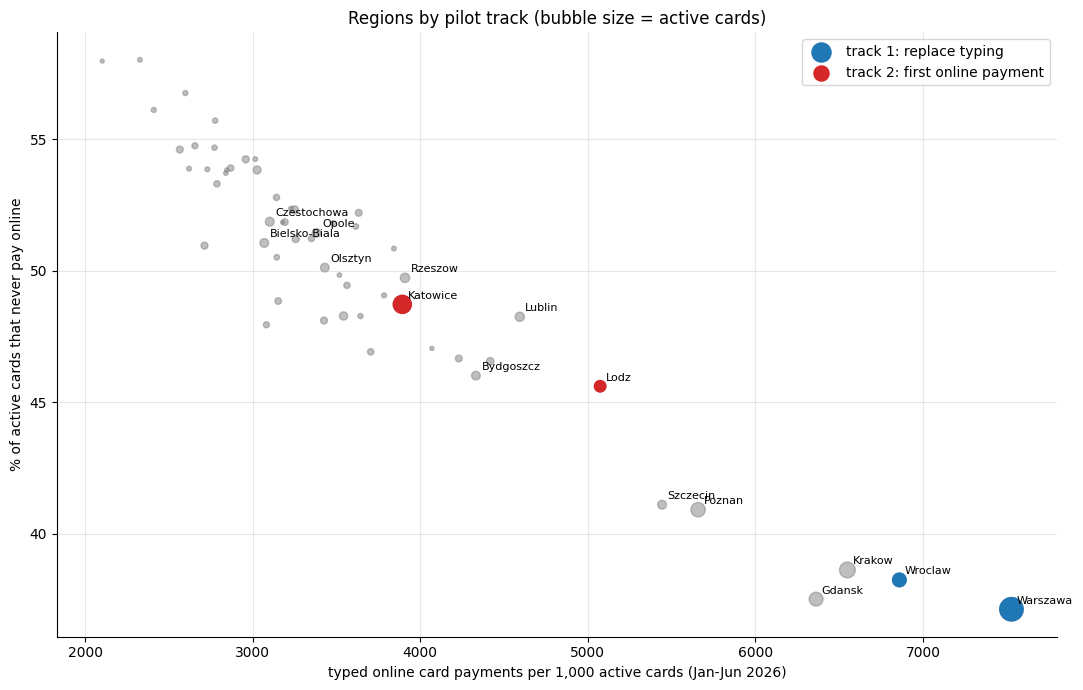

In [5]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(reg.typed_per_1000, reg.never_online_share * 100, s=reg.active_cards / 400, alpha=0.5, color="grey")
for regions, color, label in [(pilots_replace, "C0", "track 1: replace typing"),
                              (pilots_first, "C3", "track 2: first online payment")]:
    sel = reg[reg.region.isin(regions)]
    ax.scatter(sel.typed_per_1000, sel.never_online_share * 100, s=sel.active_cards / 400, color=color, label=label)
for _, r in reg.nlargest(15, "active_cards").iterrows():
    ax.annotate(r.region.title(), (r.typed_per_1000, r.never_online_share * 100), fontsize=8, xytext=(4, 4),
                textcoords="offset points")
ax.set_xlabel("typed online card payments per 1,000 active cards (Jan-Jun 2026)")
ax.set_ylabel("% of active cards that never pay online")
ax.set_title("Regions by pilot track (bubble size = active cards)")
ax.legend()
plt.tight_layout()

## 4. Control regions: nearest neighbour on behaviour + pre-trend check

Matching features (z-scored): online share, typing share, typed per 1,000, expected starters per 1,000,
never-online share, mostly-wallet share, new-card share, log size. Pilot regions cannot be controls.

In [6]:
MATCH = ["online_share", "typing_share", "typed_per_1000", "starters_per_1000", "never_online_share",
         "mostly_wallet_share", "new_card_share", "log_cards"]
Zm = pd.DataFrame(StandardScaler().fit_transform(reg[MATCH].fillna(0)), index=reg.region, columns=MATCH)
pilots = pilots_replace + pilots_first
candidates = [r for r in Zm.index if r not in pilots]

pairs, used = [], set()
for track, regions in [("replace typing", pilots_replace), ("first online payment", pilots_first)]:
    for pilot in regions:
        dist = np.sqrt(((Zm.loc[candidates] - Zm.loc[pilot]) ** 2).sum(axis=1))
        dist = dist.drop([c for c in used if c in dist.index]).sort_values()
        control = dist.index[0]
        used.add(control)
        pairs.append({"track": track, "pilot": pilot, "control": control, "distance": dist.iloc[0],
                      "runner_up": dist.index[1]})
pairs = pd.DataFrame(pairs)
pairs

,track,pilot,control,distance,runner_up
0,replace typing,WARSZAWA,GDANSK,2.00,KRAKOW
1,replace typing,WROCLAW,POZNAN,2.14,KRAKOW
2,first online payment,KATOWICE,RZESZOW,2.27,LUBLIN
3,first online payment,LODZ,LUBLIN,1.42,BYDGOSZCZ


In [7]:
# Pre-trends: monthly share of active cards paying online, Jan 2025 - Jun 2026
regions_needed = set(pairs.pilot) | set(pairs.control)
trend = con.sql(f'''
    SELECT a.home_fua AS region, p.month,
           avg((p.n_online > 0)::INT) AS online_share,
           sum(p.n_online_manual) / nullif(sum(p.n_online), 0) AS typing_share,
           count(*) AS cards
    FROM panel p JOIN attrs a USING (card)
    WHERE a.home_fua IN ({", ".join(f"'{r}'" for r in regions_needed)})
    GROUP BY 1, 2 ORDER BY 1, 2
''').df()
trend["date"] = pd.to_datetime(trend.month.astype(str), format="%Y%m")

def pretrend_gap(pilot, control, col):
    a = trend[trend.region == pilot].set_index("date")[col]
    b = trend[trend.region == control].set_index("date")[col]
    diff = (a - b).dropna()
    slope = np.polyfit(np.arange(len(diff)), diff.values, 1)[0] * 12  # change of the gap per year
    return pd.Series({f"{col}_corr": a.corr(b), f"{col}_gap_drift_per_year_pp": slope * 100})

checks = pd.concat([pairs[["pilot", "control"]],
                    pairs.apply(lambda r: pd.concat([pretrend_gap(r.pilot, r.control, "online_share"),
                                                     pretrend_gap(r.pilot, r.control, "typing_share")]), axis=1)],
                   axis=1)
checks

,pilot,control,online_share_corr,online_share_gap_drift_per_year_pp,typing_share_corr,typing_share_gap_drift_per_year_pp
0,WARSZAWA,GDANSK,0.99,-0.09,0.92,0.70
1,WROCLAW,POZNAN,0.99,0.38,0.91,-0.00
2,KATOWICE,RZESZOW,0.98,0.21,0.77,-0.02
3,LODZ,LUBLIN,0.98,0.69,0.82,-1.15


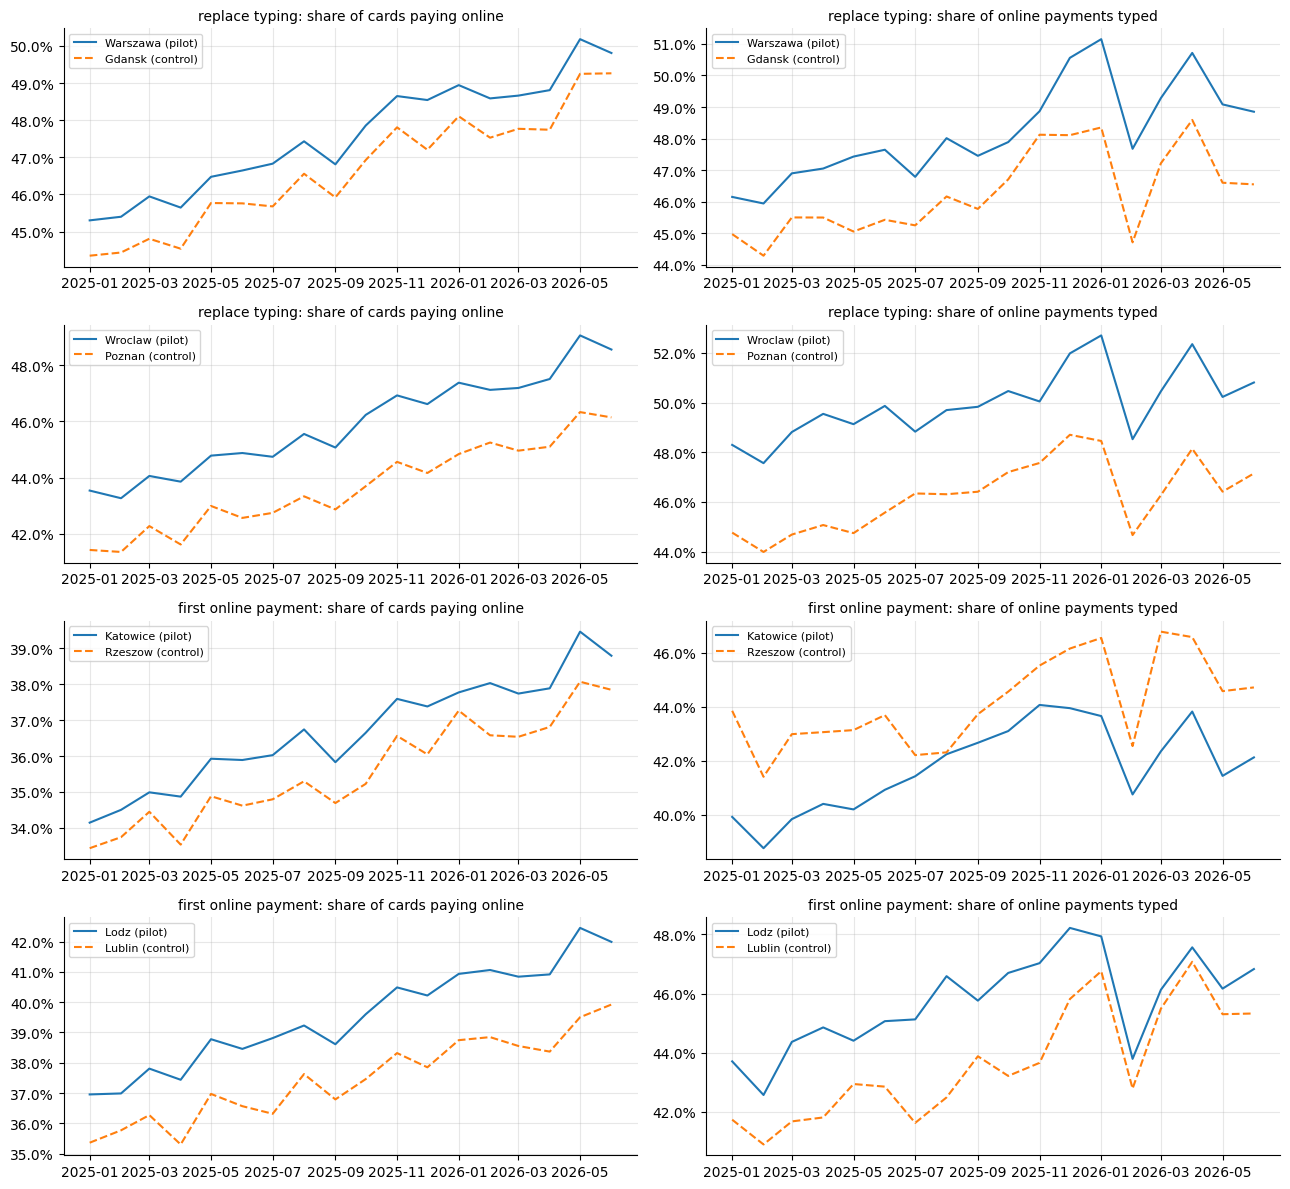

In [8]:
fig, axes = plt.subplots(len(pairs), 2, figsize=(13, 3 * len(pairs)), squeeze=False)
for i, r in pairs.iterrows():
    for j, (col, title) in enumerate([("online_share", "share of cards paying online"),
                                      ("typing_share", "share of online payments typed")]):
        ax = axes[i, j]
        for region, style in [(r.pilot, "-"), (r.control, "--")]:
            d = trend[trend.region == region]
            ax.plot(d.date, d[col] * 100, style, label=f"{region.title()} ({'pilot' if region == r.pilot else 'control'})")
        ax.set_title(f"{r.track}: {title}", fontsize=10)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(100))
        ax.legend(fontsize=8)
plt.tight_layout()

## 5. Export for the dashboard

In [9]:
export = {
    "as_of": "2026-07 (features Jan-Jun 2026)",
    "method": "readiness model scores summed per home area; nearest-neighbour control matching",
    "min_region_cards": MIN_REGION_CARDS,
    "regions": reg[["region", "active_cards", "online_share", "typing_share", "mostly_typing_share",
                    "typed_per_1000", "starters_per_1000", "expected_starters", "never_online_share",
                    "mostly_wallet_share", "new_card_share", "mean_score", "mde_replace_pp", "mde_first_pp",
                    "score_replace", "score_first"]]
               .round(4).to_dict(orient="records"),
    "pilots": pairs.round(3).to_dict(orient="records"),
    "pretrend_checks": checks.round(4).to_dict(orient="records"),
}
# Aggregated regions only (>= 3,000 cards): safe to commit, used by the dashboard
out = Path("results") / "pilot_regions.json"
out.write_text(json.dumps(export, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"saved {out}")

saved results\pilot_regions.json


## Verdict (snapshot Jul 2026)

The model scores 274k never-online active cards; about 14.8k (5.4%) are expected to make a first online card
payment within 3 months (calibration check on Apr 2026: predicted 4.92% = actual 4.92%). Only 6-7 of 57 regions
are large enough to measure a +1 pp pilot effect.

| Track | Pilot | Control | Why the pilot | Pre-trend: online share (corr / gap drift per year) |
|---|---|---|---|---|
| Replace typing | **Warszawa** | Gdansk | most typed online card payments per card (7.5k per 1,000 cards / 6 months), largest base | 0.99 / -0.1 pp |
| Replace typing | **Wroclaw** | Poznan | highest share of cards that mostly type (29%) | 0.99 / +0.4 pp |
| First online payment | **Katowice** | Rzeszow | half of active cards never pay online (49%) and the most expected first-time online payers outside Warszawa (~1.2k in 3 months) | 0.98 / +0.2 pp |
| First online payment | **Lodz** | Lublin | 46% never online, measurable size | 0.98 / +0.7 pp |

- Controls follow their pilot almost in parallel before the pilot (correlation 0.98-0.99, gap drifting by
  less than 1 pp per year), so a difference after launch can be attributed to the pilot.
- Typing-share trends match less closely for the track-2 pairs (0.77-0.82): use online share as the main KPI there.
- Readiness *per card* barely differs between large regions; what differs is how many cards already pay online and
  how much they type. Region choice is therefore driven by the size of each problem, not by the model alone.

**Limitations:** synthetic data (cities illustrate the method); region = cardholder's home area; neighbouring
regions can influence each other (e.g. marketing spill-over), so a pilot and its control should not share media markets.
